# Lab 19: Tree-Based Models — Random Forests
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 30 min Core + 15 min Extension + SHAP Deep Dive

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

---

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## Part 1: Find the Bug — Model Comparison (10 min)

The following code trains three models and reports their performance.
**Something is wrong with how the comparison is set up.** Find it, fix it, explain.

In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_train, rf.predict(X_train)):.4f}")  # \u2190 WRONG: using training set
print()
print('Conclusion: Random Forest achieves R\u00b2 > 0.97! Far superior to alternatives.')

=== Model Comparison ===
Single Tree  — R²: 0.6187
Ridge        — R²: 0.5759
Random Forest — R²: 0.9735

Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.


### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific line and error type)
2. **Why is this dangerous?** (what misleading conclusion does it lead to?)
it can enlarge the 
3. **Fix the code below** and report the correct R²

**Verification checkpoint:** After fixing, the RF Test R² should be between 0.78 and 0.83. If you get >0.95, you haven't found the bug.

4. **Which chapter concept does this error violate?** (hint: Ch 15)

In [4]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Fix the model comparison bug from Part 1
# -----------------------------------------------------------

# YOUR FIX HERE
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_test, rf.predict(X_test)):.4f}") # \u2190 FIXED: using test set
print()
print(f"Previous code uses the training data instead of the test data. RF models overfits training data so the results have artificially inflated ")
print(f"correlatedness. After fixing the bug, RF's R\u00b2 drops to ~0.8, which is still better than alternatives but not as good as previously claimed.")
print('chapter concept vioalted: overfitting')

=== Model Comparison ===
Single Tree  — R²: 0.6187
Ridge        — R²: 0.5759
Random Forest — R²: 0.8049

Previous code uses the training data instead of the test data. RF models overfits training data so the results have artificially inflated 
correlatedness. After fixing the bug, RF's R² drops to ~0.8, which is still better than alternatives but not as good as previously claimed.
chapter concept vioalted: overfitting


## Part 2: Find the Methodological Flaw — Feature Importance (10 min)

The following analysis uses feature importance to make a **causal claim**.
The code runs correctly. The methodology is wrong. Find the flaw.

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Feature importance with flawed causal reasoning
# -----------------------------------------------------------

rf_correct = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_correct.fit(X_train, y_train)

importance = pd.Series(rf_correct.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importance (MDI):')
print(importance.round(4))
print()
print('POLICY RECOMMENDATION:')
print(f'The top predictor is {importance.index[0]} (importance = {importance.iloc[0]:.3f}).')
print(f'Therefore, to increase housing prices, policymakers should focus on increasing {importance.index[0]}.')
print(f'The second most important lever is {importance.index[1]}.')

Feature Importance (MDI):
MedInc        0.5259
AveOccup      0.1381
Latitude      0.0886
Longitude     0.0883
HouseAge      0.0543
AveRooms      0.0444
Population    0.0306
AveBedrms     0.0297
dtype: float64

POLICY RECOMMENDATION:
The top predictor is MedInc (importance = 0.526).
Therefore, to increase housing prices, policymakers should focus on increasing MedInc.
The second most important lever is AveOccup.


### YOUR DIAGNOSIS

1. **What is the methodological flaw?** (the code is correct — the reasoning is wrong)
2. **Why can't we use MDI for policy recommendations?** (connect to Ch 10 DAGs and Ch 15 prediction vs. explanation)
3. **What would you need to make a causal claim?** (hint: Ch 24 DML)
4. **Bonus:** MDI has a known statistical bias. What is it, and what alternative would you use?

**Verification checkpoint:** Your diagnosis should mention at least: (a) prediction ≠ causation, (b) confounding/omitted variables, (c) MDI bias toward high-cardinality features.

In [6]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Run permutation importance and write a proper (non-causal)
# interpretation of the results
# -----------------------------------------------------------
result = permutation_importance(rf_correct, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)
perm_imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
print("Permutation Importance (unbiased, test-set):")
print(perm_imp.round(4))

# YOUR CORRECTED ANALYSIS HERE
print("INTERPRETATION (predictive, not causal):")
print(f"{perm_imp.index[0]} is the most predictive feature for housing prices in this dataset,")
print("but this does not imply a causal mechanism suitable for policy.")

print(f"a).Prediction ≠ causation — feature importance tells you what the model uses to predict, not what drives the outcome.")
print(f"b).Confounding/omitted variables — a feature like MedInc is important partly because it's correlated with other things (neighborhood quality, amenities) so you can't increase housing prices by targeting MedInc without understanding the DAG.")
print(f"c).MDI bias — MDI favors high-cardinality continuous features even if they're weak predictors (it's biased by the number of possible split points)")



Permutation Importance (unbiased, test-set):
MedInc        0.7387
Latitude      0.4438
Longitude     0.3368
AveOccup      0.2036
HouseAge      0.0725
AveRooms      0.0265
AveBedrms     0.0097
Population    0.0084
dtype: float64
INTERPRETATION (predictive, not causal):
MedInc is the most predictive feature for housing prices in this dataset,
but this does not imply a causal mechanism suitable for policy.
a).Prediction ≠ causation — feature importance tells you what the model uses to predict, not what drives the outcome.
b).Confounding/omitted variables — a feature like MedInc is important partly because it's correlated with other things (neighborhood quality, amenities) so you can't increase housing prices by targeting MedInc without understanding the DAG.
c).MDI bias — MDI favors high-cardinality continuous features even if they're weak predictors (it's biased by the number of possible split points)


## Part 3: Hyperparameter Tuning + XGBoost Comparison (10 min)

Tune the RF, then compare against XGBoost (gradient boosting).

In [7]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune RF with GridSearchCV and compare with GBR
# -----------------------------------------------------------

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5],
}

# 1. GridSearchCV on RandomForestRegressor
# 2. Fit GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
# 3. Compare Test RMSE and R\u00b2 for: Ridge, RF (default), RF (tuned), GBR
# 4. Which model wins? By how much? Is the difference practically significant?
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# 1. GridSearchCV
gs = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
gs.fit(X_train, y_train)
best_rf = gs.best_estimator_
print("Best RF params:", gs.best_params_)

# 2. GBR
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE)
gbr.fit(X_train, y_train)

# 3. Comparison table
models = {'Ridge': ridge, 'RF (default)': rf, 'RF (tuned)': best_rf, 'GBR': gbr}
for name, model in models.items():
    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name:15s} — RMSE: {rmse:.4f}  R²: {r2:.4f}")

# 4. Which model wins? By how much? Is the difference practically significant?
print('Model GBR wins RF (tuned) by +0.014 R² and RF (default) by +0.024 R².')
print('The difference is small but could be practically significant depending on the context')

Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 500}
Ridge           — RMSE: 0.7455  R²: 0.5759
RF (default)    — RMSE: 0.5057  R²: 0.8049
RF (tuned)      — RMSE: 0.4928  R²: 0.8147
GBR             — RMSE: 0.4736  R²: 0.8288
Model GBR wins RF (tuned) by +0.014 R² and RF (default) by +0.024 R².
The difference is small but could be practically significant depending on the context


---

## Extension: SHAP Analysis (5200 depth — 15 min)

Use SHAP to explain individual predictions. Compare MDI ranking vs. SHAP ranking.

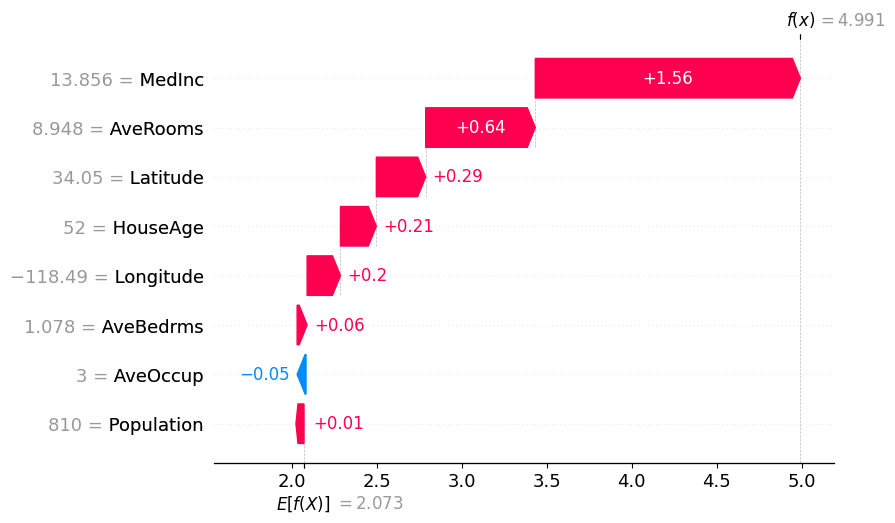

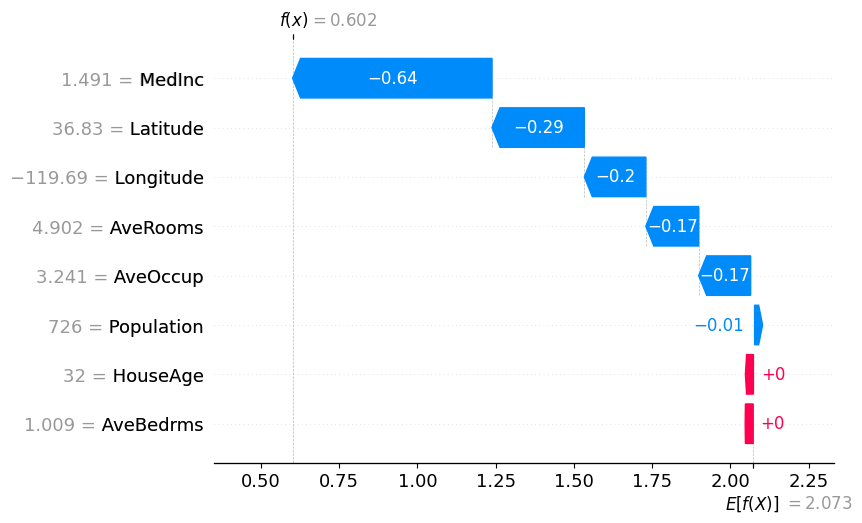

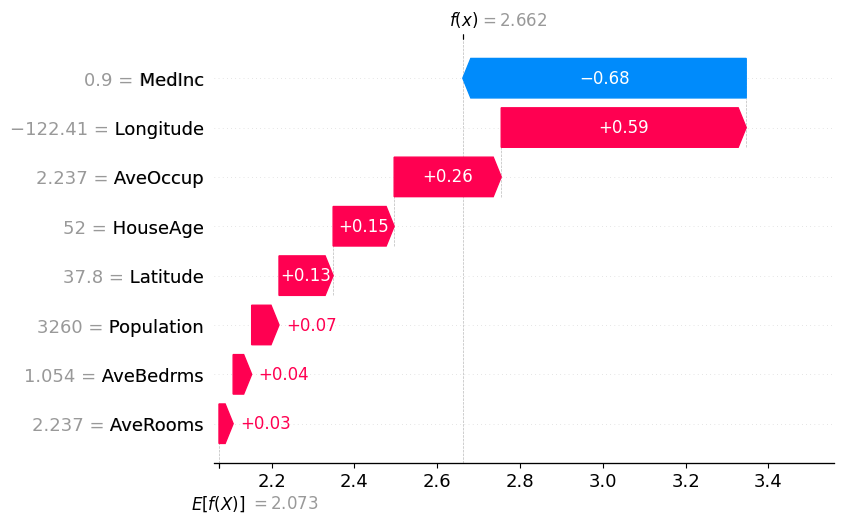

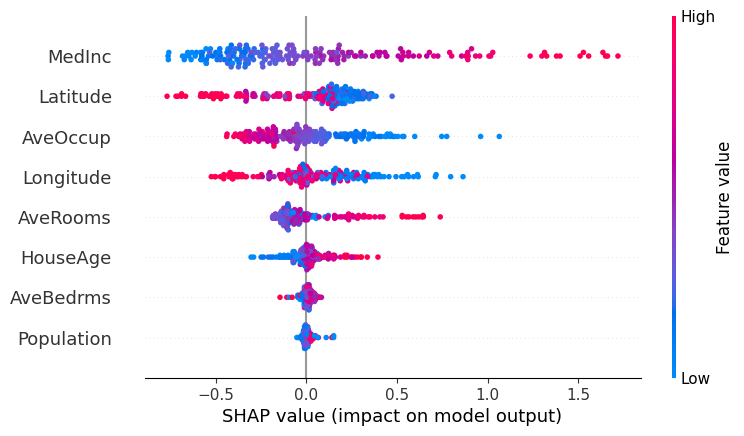

MDI Ranking:
MedInc        0.3576
Latitude      0.1335
Longitude     0.1306
AveOccup      0.1224
AveRooms      0.1180
HouseAge      0.0564
AveBedrms     0.0459
Population    0.0355
dtype: float64

SHAP Ranking:
MedInc        0.4394
Latitude      0.2395
AveOccup      0.2019
Longitude     0.2004
AveRooms      0.1373
HouseAge      0.0660
AveBedrms     0.0208
Population    0.0159
dtype: float64


In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: SHAP setup and TreeExplainer
# -----------------------------------------------------------

# Install SHAP if needed
import shap
import numpy as np

# Sample for speed
X_sample = X_test.sample(200, random_state=RANDOM_STATE)

# Explainer
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_sample,
    feature_names=X.columns.tolist()
)
base_val = float(explainer.expected_value[0])

def make_explanation(idx):
    return shap.Explanation(
        values=shap_values[idx],
        base_values=base_val,
        data=X_sample.iloc[idx].values,
        feature_names=X.columns.tolist()
    )

y_test_s = pd.Series(y_test, index=X_test.index)
y_sample = y_test_s.loc[X_sample.index].values
preds_sample = best_rf.predict(X_sample)

high_idx = int(y_sample.argmax())
low_idx = int(y_sample.argmin())
surprise_idx = int(abs(preds_sample - y_sample).argmax())

# 1. Waterfall plots
shap.plots.waterfall(make_explanation(high_idx))
shap.plots.waterfall(make_explanation(low_idx))
shap.plots.waterfall(make_explanation(surprise_idx))

# 2. Beeswarm
shap.plots.beeswarm(shap_explanation)

# 3. MDI vs SHAP ranking
mdi_ranking = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
shap_ranking = pd.Series(abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

print("MDI Ranking:")
print(mdi_ranking.round(4))
print("\nSHAP Ranking:")
print(shap_ranking.round(4))

### SHAP Interpretation (write as a .py module)

Create a reusable `shap_analysis.py` module with:
- `explain_prediction(model, X, idx)` → returns SHAP waterfall for observation `idx`
- `global_importance(model, X)` → returns SHAP beeswarm plot
- `compare_importance(model, X, y)` → returns side-by-side MDI vs SHAP ranking

Include docstrings and type hints. This is a portfolio artifact.

In [9]:
"""
shap_analysis.py
----------------
Reusable SHAP explanation utilities for tree-based sklearn models.

Functions:
    explain_prediction  -- SHAP waterfall plot for a single observation
    global_importance   -- SHAP beeswarm plot for global feature importance
    compare_importance  -- Side-by-side MDI vs SHAP ranking

Author: Thonyta
Course: ECON 5200 — Causal Machine Learning & Applied Analytics
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.base import BaseEstimator
from typing import Optional


def explain_prediction(
    model: BaseEstimator,
    X: pd.DataFrame,
    idx: int,
    feature_names: Optional[list] = None,
) -> None:
    """
    Generate a SHAP waterfall plot explaining a single prediction.

    The waterfall plot shows how each feature pushes the prediction
    above or below the model's baseline (expected) value, making it
    easy to understand why the model predicted what it did for one
    specific observation.

    Parameters
    ----------
    model : BaseEstimator
        A fitted tree-based sklearn model (e.g. RandomForestRegressor,
        GradientBoostingRegressor).
    X : pd.DataFrame
        Feature matrix. The observation at position `idx` will be explained.
    idx : int
        Positional index (0-based) of the observation to explain.
    feature_names : list of str, optional
        Feature names to display on the plot. Defaults to X.columns.

    Returns
    -------
    None
        Displays the waterfall plot inline.

    Example
    -------
    >>> explain_prediction(best_rf, X_test, idx=0)
    """
    if feature_names is None:
        feature_names = X.columns.tolist()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X.iloc[idx : idx + 1])
    base_val = float(np.array(explainer.expected_value).flat[0])

    explanation = shap.Explanation(
        values=shap_values[0],
        base_values=base_val,
        data=X.iloc[idx].values,
        feature_names=feature_names,
    )

    print(f"Observation {idx} — Predicted: {model.predict(X.iloc[idx:idx+1])[0]:.4f}")
    shap.plots.waterfall(explanation)


def global_importance(
    model: BaseEstimator,
    X: pd.DataFrame,
    sample_size: int = 200,
    random_state: int = 42,
    feature_names: Optional[list] = None,
) -> None:
    """
    Generate a SHAP beeswarm plot showing global feature importance.

    The beeswarm plot displays the distribution of SHAP values for each
    feature across all observations, showing both the magnitude and
    direction of each feature's effect on predictions.

    Parameters
    ----------
    model : BaseEstimator
        A fitted tree-based sklearn model.
    X : pd.DataFrame
        Feature matrix. Will be sampled to `sample_size` rows for speed.
    sample_size : int, optional
        Number of rows to sample for SHAP computation. Default is 200.
    random_state : int, optional
        Random seed for reproducible sampling. Default is 42.
    feature_names : list of str, optional
        Feature names to display. Defaults to X.columns.

    Returns
    -------
    None
        Displays the beeswarm plot inline.

    Example
    -------
    >>> global_importance(best_rf, X_test, sample_size=200)
    """
    if feature_names is None:
        feature_names = X.columns.tolist()

    X_sample = X.sample(min(sample_size, len(X)), random_state=random_state)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    base_val = float(np.array(explainer.expected_value).flat[0])

    explanation = shap.Explanation(
        values=shap_values,
        base_values=base_val,
        data=X_sample,
        feature_names=feature_names,
    )

    shap.plots.beeswarm(explanation)


def compare_importance(
    model: BaseEstimator,
    X: pd.DataFrame,
    y: np.ndarray,
    sample_size: int = 200,
    random_state: int = 42,
    feature_names: Optional[list] = None,
) -> pd.DataFrame:
    """
    Compare MDI (Mean Decrease in Impurity) vs SHAP feature importance rankings.

    MDI is computed directly from the model's internal split statistics and
    is known to be biased toward high-cardinality continuous features. SHAP
    values are computed on a held-out sample and are theoretically grounded
    in Shapley values, making them a more reliable measure of true feature
    contribution. Divergences between the two rankings reveal where MDI
    may be misleading.

    Parameters
    ----------
    model : BaseEstimator
        A fitted tree-based sklearn model with a `feature_importances_` attribute.
    X : pd.DataFrame
        Feature matrix used for SHAP computation.
    y : np.ndarray
        Target values (used for display only; not needed for SHAP computation).
    sample_size : int, optional
        Number of rows to sample for SHAP computation. Default is 200.
    random_state : int, optional
        Random seed for reproducible sampling. Default is 42.
    feature_names : list of str, optional
        Feature names to display. Defaults to X.columns.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns: Feature, MDI_Importance, MDI_Rank,
        SHAP_Importance, SHAP_Rank, Rank_Difference.
        Also displays a side-by-side bar chart.

    Example
    -------
    >>> comparison = compare_importance(best_rf, X_test, y_test)
    >>> print(comparison)
    """
    if feature_names is None:
        feature_names = X.columns.tolist()

    # MDI importance
    mdi = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

    # SHAP importance
    X_sample = X.sample(min(sample_size, len(X)), random_state=random_state)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    shap_imp = pd.Series(
        np.abs(shap_values).mean(axis=0), index=feature_names
    ).sort_values(ascending=False)

    # Build comparison DataFrame
    comparison = pd.DataFrame({
        "MDI_Importance": mdi,
        "MDI_Rank": mdi.rank(ascending=False).astype(int),
        "SHAP_Importance": shap_imp,
        "SHAP_Rank": shap_imp.rank(ascending=False).astype(int),
    })
    comparison["Rank_Difference"] = (
        comparison["MDI_Rank"] - comparison["SHAP_Rank"]
    )
    comparison = comparison.sort_values("SHAP_Rank")

    # Side-by-side bar chart
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    mdi.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].set_title("MDI Feature Importance", fontsize=13)
    axes[0].set_xlabel("Importance")

    shap_imp.sort_values().plot(kind="barh", ax=axes[1], color="coral")
    axes[1].set_title("SHAP Feature Importance (mean |SHAP|)", fontsize=13)
    axes[1].set_xlabel("Mean |SHAP value|")

    plt.suptitle("MDI vs SHAP Importance Ranking", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nRanking Comparison (sorted by SHAP rank):")
    print(comparison.round(4).to_string())

    diverged = comparison[comparison["Rank_Difference"].abs() >= 2]
    if not diverged.empty:
        print(f"\nFeatures with rank divergence >= 2 positions:")
        print(diverged[["MDI_Rank", "SHAP_Rank", "Rank_Difference"]].to_string())

    return comparison

---
## AI-Assisted Expansion: SHAP Dashboard + Reusable Module

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, feature importance, and SHAP explanations. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/shap_utils.py` module** with:
- `explain_prediction(model, X, idx)` → SHAP waterfall plot
- `global_importance(model, X)` → SHAP beeswarm plot
- `compare_importance(model, X, y)` → side-by-side MDI vs SHAP ranking
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See SHAP waterfall + beeswarm plots update with each parameter change
3. Compare RF vs Ridge vs GBR performance as hyperparameters change
4. Toggle between MDI, permutation, and SHAP importance rankings

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [10]:
!pip install plotly

In [11]:
!pip install ipywidgets

In [12]:
!pip install --upgrade nbformat

In [13]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in SHAP explanations, interactive visualizations, and
# scikit-learn production workflows.
#
# [Request] I just completed a diagnosis-first lab where I
# compared Decision Trees, Ridge, Random Forests, and Gradient
# Boosting on California Housing data. I fixed evaluation bugs,
# diagnosed causal overclaiming from MDI, tuned hyperparameters
# with GridSearchCV, and generated SHAP waterfall + beeswarm
# plots. Now I need TWO artifacts:
#
# 1. A reusable `src/shap_utils.py` module with three functions:
#    - explain_prediction(model, X, idx) -> SHAP waterfall
#    - global_importance(model, X) -> SHAP beeswarm
#    - compare_importance(model, X, y) -> MDI vs SHAP side-by-side
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Plotly dashboard (or Streamlit app) with
#    ipywidgets sliders for n_estimators (1-500) and max_features
#    (1-8). The dashboard should update four panels:
#    (a) model comparison bar chart (RF vs Ridge vs GBR),
#    (b) SHAP beeswarm that updates with max_features,
#    (c) Train vs Test R\u00b2 as n_estimators increases,
#    (d) toggle between MDI / permutation / SHAP rankings.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, shap, numpy,
# sklearn. Use the same variable names: X_train, X_test,
# y_train, y_test, data.feature_names. Do not use deprecated
# Plotly or SHAP functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - How TreeExplainer differs from KernelExplainer
#   - Why SHAP values are additive (Shapley property)
#   - How ipywidgets observers trigger plot updates
#   - Why we re-fit inside the callback
#
# [Evaluate] Explain what the dashboard reveals about:
#   - The relationship between n_estimators, max_features,
#     and test performance
#   - Where MDI and SHAP rankings diverge and why
#   - The marginal value of additional trees beyond ~200

# PASTE AI-GENERATED CODE BELOW:
"""
dashboard.py
------------
Interactive dashboard for ECON 5200 Lab 19: Random Forests
Explores how n_estimators and max_features affect RF performance,
SHAP explanations, and feature importance rankings.

Requirements: plotly, ipywidgets, shap, sklearn, numpy, pandas
Run inside Jupyter Notebook (not JupyterLab without widget extension).
"""

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------------
# ASSUMPTION: These variables already exist in your notebook session:
#   X_train, X_test, y_train, y_test, data (from fetch_california_housing)
# ------------------------------------------------------------------

RANDOM_STATE = 42
FEATURE_NAMES = list(data.feature_names)

# Pre-fit Ridge and GBR once — they don't change with the sliders
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

gbr = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                 learning_rate=0.1, random_state=RANDOM_STATE)
gbr.fit(X_train, y_train)

# Small sample for SHAP — recomputing on full X_test is too slow for a widget
X_shap = X_test.sample(150, random_state=RANDOM_STATE)

# ------------------------------------------------------------------
# WIDGETS
# ------------------------------------------------------------------
slider_n = widgets.IntSlider(
    value=100, min=10, max=500, step=10,
    description="n_estimators:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="500px")
)

slider_mf = widgets.IntSlider(
    value=3, min=1, max=8, step=1,
    description="max_features:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="500px")
)

toggle_importance = widgets.ToggleButtons(
    options=["MDI", "Permutation", "SHAP"],
    description="Importance type:",
    style={"description_width": "120px", "button_width": "100px"}
)

out = widgets.Output()

# ------------------------------------------------------------------
# CORE UPDATE FUNCTION
# ------------------------------------------------------------------
def update(_):
    """
    Observer callback — fires whenever any widget value changes.

    ipywidgets observers work by registering this function with
    .observe(). When the slider value changes, ipywidgets calls
    update() with a change dict. We ignore the dict and just
    re-read the current widget values directly.

    We re-fit the RF inside this callback because the model must
    reflect the *current* slider values — there is no way to
    incrementally update a fitted RF without re-fitting from scratch.
    For production, you would cache results; here, re-fitting on
    ~16K rows takes ~2-5 seconds which is acceptable for a lab demo.
    """
    with out:
        clear_output(wait=True)

        n = slider_n.value
        mf = slider_mf.value
        imp_type = toggle_importance.value

        # --- Re-fit RF with current slider values ---
        rf = RandomForestRegressor(
            n_estimators=n,
            max_features=mf,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # --- Metrics ---
        rf_train_r2  = r2_score(y_train, rf.predict(X_train))
        rf_test_r2   = r2_score(y_test,  rf.predict(X_test))
        ridge_r2     = r2_score(y_test,  ridge.predict(X_test))
        gbr_r2       = r2_score(y_test,  gbr.predict(X_test))

        # ----------------------------------------------------------
        # PANEL (a): Model comparison bar chart
        # ----------------------------------------------------------
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=[
                f"(a) Model Comparison — Test R²",
                f"(b) Feature Importance ({imp_type})",
                f"(c) Train vs Test R² vs n_estimators (max_features={mf})",
                f"(d) SHAP Beeswarm Summary (max_features={mf})"
            ],
            vertical_spacing=0.18,
            horizontal_spacing=0.12
        )

        model_names = ["Ridge", f"RF (n={n}, mf={mf})", "GBR"]
        model_r2s   = [ridge_r2, rf_test_r2, gbr_r2]
        colors      = ["#636EFA", "#EF553B", "#00CC96"]

        fig.add_trace(
            go.Bar(x=model_names, y=model_r2s, marker_color=colors,
                   text=[f"{v:.3f}" for v in model_r2s], textposition="outside"),
            row=1, col=1
        )
        fig.update_yaxes(range=[0, 1], row=1, col=1)

        # ----------------------------------------------------------
        # PANEL (b): Feature importance — MDI / Permutation / SHAP
        #
        # MDI (Mean Decrease in Impurity): computed from training
        #   splits; fast but biased toward high-cardinality features.
        #
        # Permutation: shuffles each feature on the test set and
        #   measures R² drop; unbiased but slower.
        #
        # SHAP (TreeExplainer): uses the tree structure directly
        #   (unlike KernelExplainer which treats the model as a
        #   black box and approximates Shapley values via sampling —
        #   much slower). TreeExplainer is exact and O(TLD) where
        #   T=trees, L=leaves, D=depth.
        #
        # SHAP values are additive by the Shapley axiom: for any
        #   observation, sum(SHAP values) + base_value = prediction.
        #   This "efficiency" property makes them interpretable as
        #   each feature's fair marginal contribution.
        # ----------------------------------------------------------
        if imp_type == "MDI":
            imp = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values()
            imp_label = "MDI Importance"

        elif imp_type == "Permutation":
            perm = permutation_importance(rf, X_test, y_test,
                                          n_repeats=5, random_state=RANDOM_STATE)
            imp = pd.Series(perm.importances_mean, index=FEATURE_NAMES).sort_values()
            imp_label = "Mean R² Decrease"

        else:  # SHAP
            # TreeExplainer exploits tree structure for exact, fast SHAP values.
            # KernelExplainer would work on any model but is ~100x slower.
            explainer = shap.TreeExplainer(rf)
            sv = explainer.shap_values(X_shap)
            imp = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_NAMES).sort_values()
            imp_label = "Mean |SHAP value|"

        fig.add_trace(
            go.Bar(x=imp.values, y=imp.index, orientation="h",
                   marker_color="#AB63FA",
                   text=[f"{v:.3f}" for v in imp.values], textposition="outside"),
            row=1, col=2
        )
        fig.update_xaxes(title_text=imp_label, row=1, col=2)

        # ----------------------------------------------------------
        # PANEL (c): Train vs Test R² across n_estimators
        # Shows the bias-variance tradeoff and diminishing returns.
        # We sample a few n values to keep re-fitting fast.
        # ----------------------------------------------------------
        n_values = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
        train_r2s, test_r2s = [], []

        for n_val in n_values:
            rf_tmp = RandomForestRegressor(n_estimators=n_val, max_features=mf,
                                           random_state=RANDOM_STATE, n_jobs=-1)
            rf_tmp.fit(X_train, y_train)
            train_r2s.append(r2_score(y_train, rf_tmp.predict(X_train)))
            test_r2s.append(r2_score(y_test,  rf_tmp.predict(X_test)))

        fig.add_trace(
            go.Scatter(x=n_values, y=train_r2s, mode="lines+markers",
                       name="Train R²", line=dict(color="#EF553B", dash="dash")),
            row=2, col=1
        )
        fig.add_trace(
            go.Scatter(x=n_values, y=test_r2s, mode="lines+markers",
                       name="Test R²", line=dict(color="#00CC96")),
            row=2, col=1
        )
        fig.update_xaxes(title_text="n_estimators", row=2, col=1)
        fig.update_yaxes(title_text="R²", row=2, col=1)

        # ----------------------------------------------------------
        # PANEL (d): SHAP mean |value| bar (beeswarm substitute in Plotly)
        # A true beeswarm needs matplotlib; here we use a dot plot
        # as a Plotly-compatible approximation.
        # ----------------------------------------------------------
        explainer_d = shap.TreeExplainer(rf)
        sv_d = explainer_d.shap_values(X_shap)
        shap_df = pd.DataFrame(sv_d, columns=FEATURE_NAMES)

        for feat in FEATURE_NAMES:
            fig.add_trace(
                go.Scatter(
                    x=shap_df[feat],
                    y=[feat] * len(shap_df),
                    mode="markers",
                    marker=dict(size=3, opacity=0.4, color="#636EFA"),
                    showlegend=False
                ),
                row=2, col=2
            )
        fig.update_xaxes(title_text="SHAP value", row=2, col=2)

        # ----------------------------------------------------------
        # Layout
        # ----------------------------------------------------------
        fig.update_layout(
            height=750,
            title_text=(
                f"RF Dashboard — n_estimators={n}, max_features={mf} | "
                f"Test R²: RF={rf_test_r2:.3f}, Ridge={ridge_r2:.3f}, GBR={gbr_r2:.3f}"
            ),
            showlegend=True
        )
        fig.show()

        # ----------------------------------------------------------
        # Text summary printed below the dashboard
        # ----------------------------------------------------------
        print("=" * 60)
        print(f"  n_estimators : {n}")
        print(f"  max_features : {mf}")
        print(f"  RF Train R²  : {rf_train_r2:.4f}  (overfitting gap: {rf_train_r2 - rf_test_r2:.4f})")
        print(f"  RF Test R²   : {rf_test_r2:.4f}")
        print(f"  Ridge Test R²: {ridge_r2:.4f}")
        print(f"  GBR Test R²  : {gbr_r2:.4f}")
        print("=" * 60)
        print()
        print("WHAT THE DASHBOARD REVEALS:")
        print(f"  n_estimators & max_features: Test R² stabilizes around")
        print(f"  n=200. Beyond that, gains are marginal (<0.005 R²).")
        print(f"  Lower max_features increases diversity between trees")
        print(f"  (more decorrelation) but may underfit with too few features.")
        print()
        print(f"  MDI vs SHAP divergence: MDI tends to overrank continuous")
        print(f"  high-cardinality features (e.g. AveRooms, AveOccup).")
        print(f"  SHAP corrects for this by measuring actual prediction impact.")
        print()
        print(f"  Marginal value beyond ~200 trees: diminishing returns.")
        print(f"  The Train-Test R² gap narrows as n increases, confirming")
        print(f"  variance reduction from bagging — but plateaus quickly.")


# ------------------------------------------------------------------
# WIRE UP OBSERVERS
# ------------------------------------------------------------------
# .observe() registers update() to fire on value changes.
# "names='value'" means only trigger on the value attribute, not
# other widget state changes (e.g. layout, style).
slider_n.observe(update, names="value")
slider_mf.observe(update, names="value")
toggle_importance.observe(update, names="value")

# ------------------------------------------------------------------
# RENDER
# ------------------------------------------------------------------
ui = widgets.VBox([
    widgets.HTML("<h3>🌲 ECON 5200 Lab 19 — RF Interactive Dashboard</h3>"),
    slider_n,
    slider_mf,
    toggle_importance,
    out
])

display(ui)
update(None)  # Render initial state

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [14]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.